# Lab 07 — Reflection Seismology

**Name**: Lillian Hanson  
**Purpose**: Perform Normal Moveout (NMO) analysis on a single CMP location extracted from a synthetic multi-shot seismic dataset.

## Processing Workflow
| Step | Task |
|------|------|
| 1 | Load synthetic shot gathers |
| 2 | Calculate CMP locations for every trace |
| 3 | Plot CMP density histogram |
| 4 | Select high-density CMP, build CMP gather |
| 5 | Semblance analysis + velocity picks |
| 6 | Construct Vrms–t₀ profile |
| 7 | NMO correction |
| 8 | Far-offset mute + stacking |

---

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d

# ── Local library ─────────────────────────────────────────────────────────────
import nmo_lib as nmo

# ── Plot aesthetics ───────────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'font.family':       'DejaVu Sans',
})

print('Imports successful.')

Imports successful.


---
## Step 1 — Load Shot Gathers

Each `.npz` file stores one common-shot gather with the following fields:

| Key | Description |
|-----|-------------|
| `rx` | Receiver x-coordinates (m) |
| `rz` | Receiver z-coordinates (m) |
| `sx` | Source x-coordinate (m) |
| `sz` | Source z-coordinate (m) |
| `dt` | Time sampling interval (ms) |
| `data` | Seismic amplitudes, shape `(n_samples, n_traces)` |

In [2]:
# ── Path configuration ────────────────────────────────────────────────────────
DATA_FOLDER = 'multi_shots'          
FILE_PATTERN = 'shot_*.npz'          # files are named shot_0.npz, shot_1.npz, …

# ── Load all shot gathers using nmo_lib ───────────────────────────────────────
shots = nmo.load_shot_gathers(DATA_FOLDER, pattern=FILE_PATTERN)

# ── Inspect the first shot gather ─────────────────────────────────────────────
s0 = shots[0]
n_samples, n_traces = s0['data'].shape
dt = s0['dt']
t_axis = np.arange(n_samples) * dt

print(f"\n── Shot 0 summary ──")
print(f"  File          : {s0['file']}")
print(f"  Traces        : {n_traces}")
print(f"  Time samples  : {n_samples}")
print(f"  dt            : {dt:.4f} ms")
print(f"  Record length : {t_axis[-1]:.1f} ms")
print(f"  Source x      : {s0['sx']:.1f} m")
print(f"  Receiver x    : {s0['rx'].min():.1f} – {s0['rx'].max():.1f} m")

Loaded 20 shot gather(s) from 'multi_shots'.

── Shot 0 summary ──
  File          : Shot_0.npz
  Traces        : 40
  Time samples  : 1544
  dt            : 1.2970 ms
  Record length : 2001.3 ms
  Source x      : 4000.0 m
  Receiver x    : 2000.0 – 6000.0 m


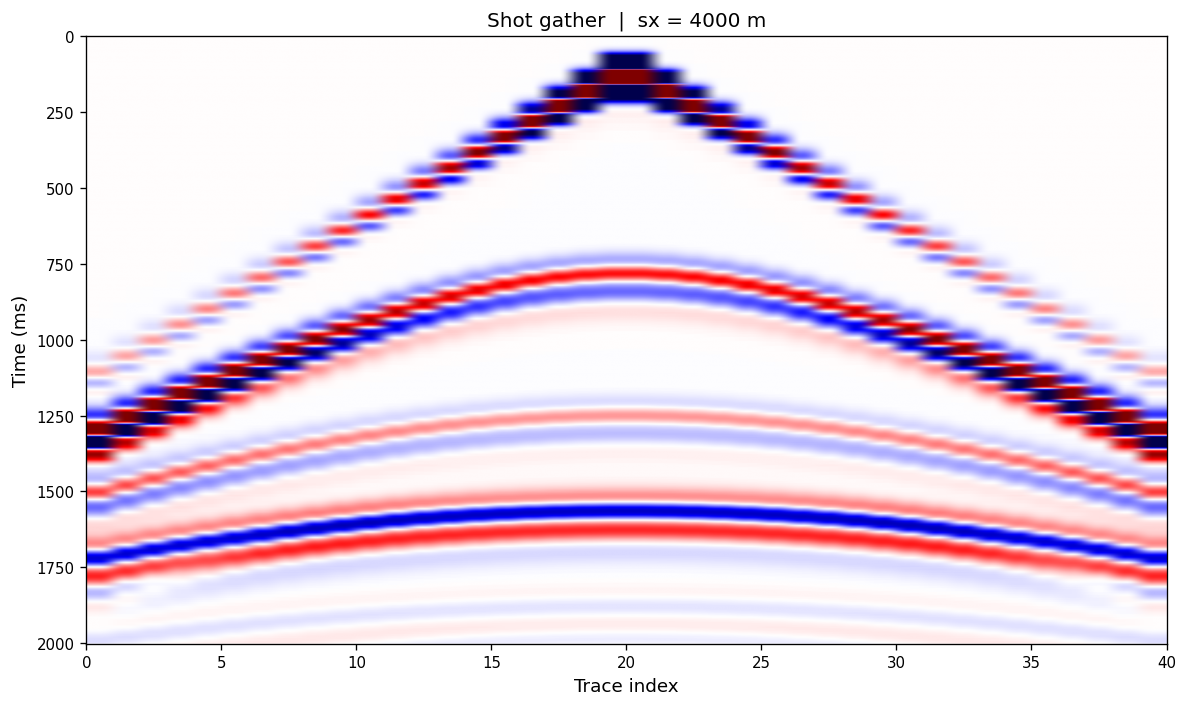

Figure 1: Common-shot gather for shot 0.


In [3]:
# ── Plot the first shot gather to verify loading ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
nmo.plot_shot_gather(shots[0], clip_pct=98, ax=ax)
plt.tight_layout()
plt.show()
print('Figure 1: Common-shot gather for shot 0.')

---
## Step 2 — Compute CMP Locations

For a 2-D survey the common-midpoint (CMP) x-coordinate of a source–receiver pair is:

$$x_{\text{CMP}} = \frac{x_s + x_r}{2}$$

The **offset** (source–receiver distance) is:

$$h = |x_r - x_s|$$

Both quantities are computed for every trace in every shot gather.

In [4]:
# ── Compute midpoints and offsets across all shots ─────────────────────────────
all_cmps, all_offsets, shot_idx, trc_idx, dt_list = nmo.compute_midpoints(shots)

print(f"Total traces (all shots) : {len(all_cmps):,}")
print(f"CMP range                : {all_cmps.min():.1f} – {all_cmps.max():.1f} m")
print(f"Offset range             : {all_offsets.min():.1f} – {all_offsets.max():.1f} m")

Total traces (all shots) : 800
CMP range                : 3000.0 – 7000.0 m
Offset range             : 51.3 – 2000.0 m


---
## Step 3 — CMP Density Histogram

A histogram of CMP x-locations reveals the **fold** (number of traces per CMP bin).
Regions with high fold give better signal-to-noise after stacking and are preferred for detailed analysis.

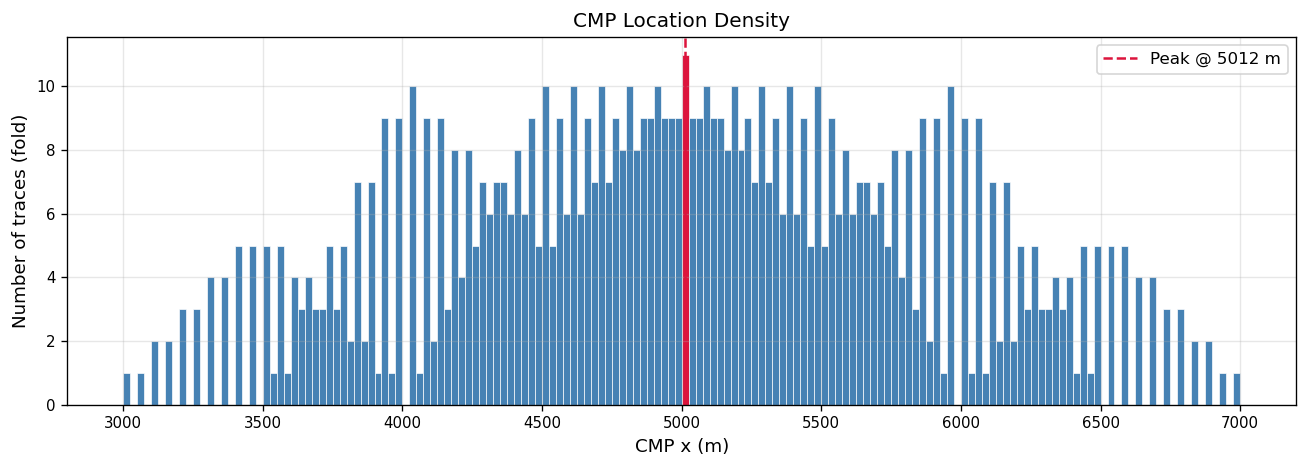

Peak CMP bin centre : 5012.5 m  (11 traces)


In [5]:
# ── CMP density histogram ──────────────────────────────────────────────────────
BIN_SIZE_HIST = 25.0          # histogram bin width in metres

fig, ax = plt.subplots(figsize=(11, 4))

counts, edges, patches = ax.hist(
    all_cmps,
    bins=np.arange(all_cmps.min(), all_cmps.max() + BIN_SIZE_HIST, BIN_SIZE_HIST),
    color='steelblue', edgecolor='white', linewidth=0.4,
)

# Highlight the peak bin
peak_idx   = np.argmax(counts)
peak_x     = 0.5 * (edges[peak_idx] + edges[peak_idx + 1])
patches[peak_idx].set_facecolor('crimson')
ax.axvline(peak_x, color='crimson', lw=1.5, ls='--', label=f'Peak @ {peak_x:.0f} m')

ax.set_xlabel('CMP x (m)')
ax.set_ylabel('Number of traces (fold)')
ax.set_title('CMP Location Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak CMP bin centre : {peak_x:.1f} m  ({int(counts[peak_idx])} traces)")

---
## Step 4 — Build the CMP Gather

We select the highest-density CMP location identified above and collect all traces
whose midpoint falls within ±`BIN_SIZE/2` of that location.  

**Bin-size choice**: A bin half-width of ~12.5 m (typical for 25 m receiver spacing)
is a reasonable starting point — wide enough to gather adequate fold but narrow enough
to avoid spatial aliasing.

CMP gather @ 5012.5 m: 19 traces, offsets 51–2000 m


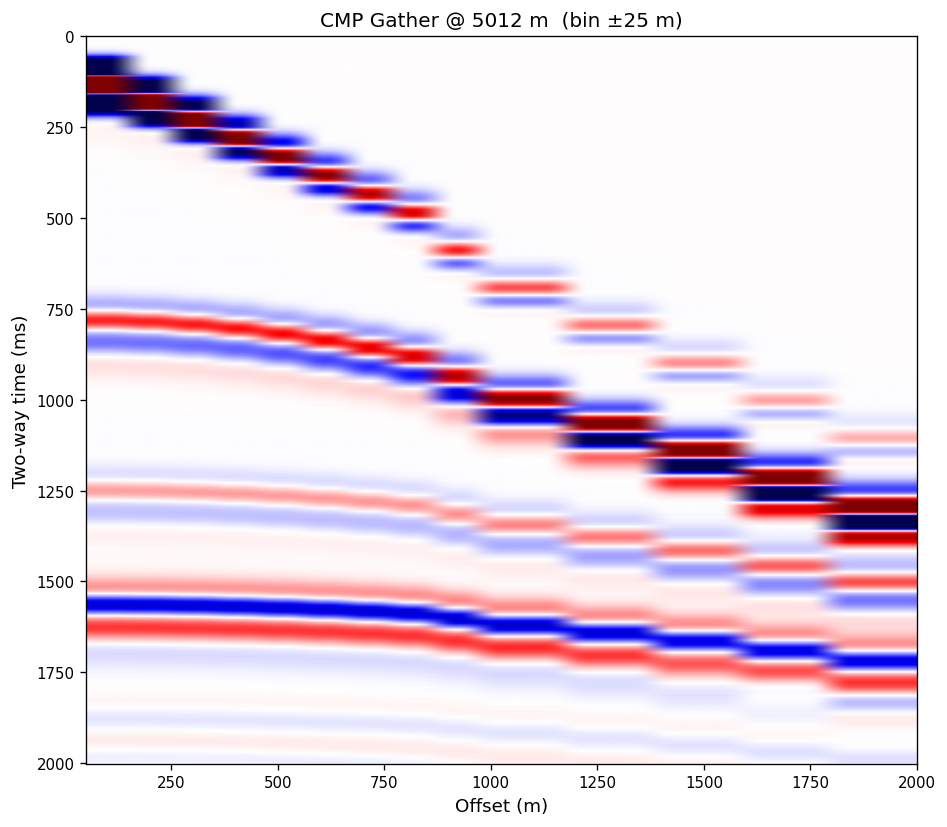

Figure 3: Raw CMP gather sorted by offset.
Hyperbolic moveout is visible on each reflection event.


In [6]:
# ── Select CMP centre and bin size ────────────────────────────────────────────
# Use the peak bin from the histogram; adjust manually if desired.
CMP_TARGET = peak_x        # meters 
BIN_SIZE   = 50.0          # meters  — full bin width (±25 m around CMP_TARGET)

# ── Build the CMP gather ──────────────────────────────────────────────────────
cmp_gather = nmo.build_cmp_gather(
    shots, all_cmps, all_offsets,
    shot_idx, trc_idx,
    cmp_center=CMP_TARGET,
    bin_size=BIN_SIZE,
)

# ── Plot raw CMP gather ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
nmo.plot_cmp_gather(
    cmp_gather,
    title=f'CMP Gather @ {CMP_TARGET:.0f} m  (bin ±{BIN_SIZE/2:.0f} m)',
    ax=ax,
)
plt.tight_layout()
plt.show()
print('Figure 3: Raw CMP gather sorted by offset.\n'
      'Hyperbolic moveout is visible on each reflection event.')

---
## Step 5 — Semblance Analysis & Velocity Picks

**Semblance** measures the coherence of NMO-corrected
amplitudes as a function of zero-offset time $t_0$ and trial RMS velocity $V_{\text{rms}}$.

For each $(t_0, V_{\text{rms}})$ pair the NMO travel-time for a trace at offset $x$ is:

$$t(x) = \sqrt{t_0^2 + \frac{x^2}{V_{\text{rms}}^2}}$$

Coherence is highest when the correct velocity flattens a reflection, producing a **bright
spot** in the semblance panel.  I hand pick the (t₀, V) pair at each bright spot.

In [14]:
# ── Semblance parameters ──────────────────────────────────────────────────────
V_MIN    = 1400.0    # m/s  — minimum trial velocity
V_MAX    = 5000.0    # m/s  — maximum trial velocity
N_V      = 120       # number of velocity samples
HALF_WIN = 3         # coherence window half-length (samples)

print('Computing semblance panel')
semblance, t0_axis, v_axis = nmo.compute_semblance(
    cmp_gather,
    v_min=V_MIN, v_max=V_MAX, n_v=N_V,
    half_win=HALF_WIN,
)
print(f'Semblance shape: {semblance.shape}  (n_t0={len(t0_axis)}, n_v={len(v_axis)})')

Computing semblance panel
Semblance shape: (1544, 120)  (n_t0=1544, n_v=120)


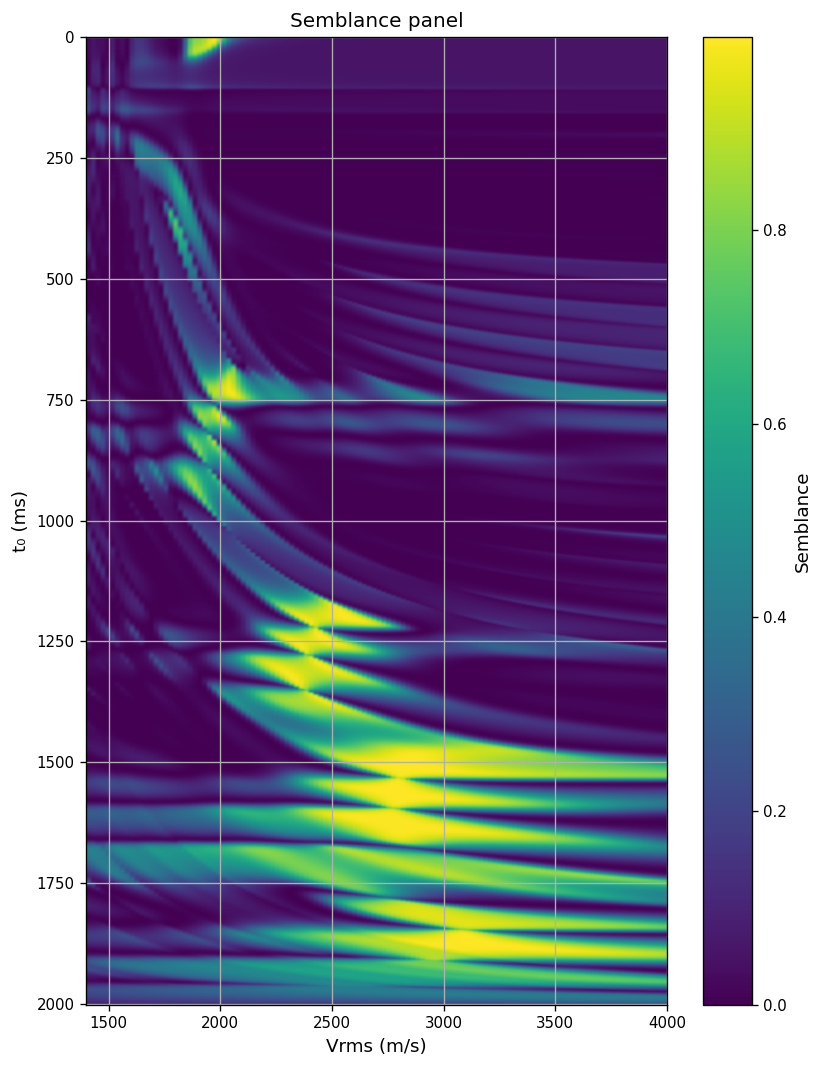

Figure 4: Semblance panel.


In [8]:
# ── Display semblance panel (before picks) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 9))
nmo.plot_semblance(semblance, t0_axis, v_axis, ax=ax)
plt.tight_layout()
plt.grid()
plt.show()
print('Figure 4: Semblance panel.')

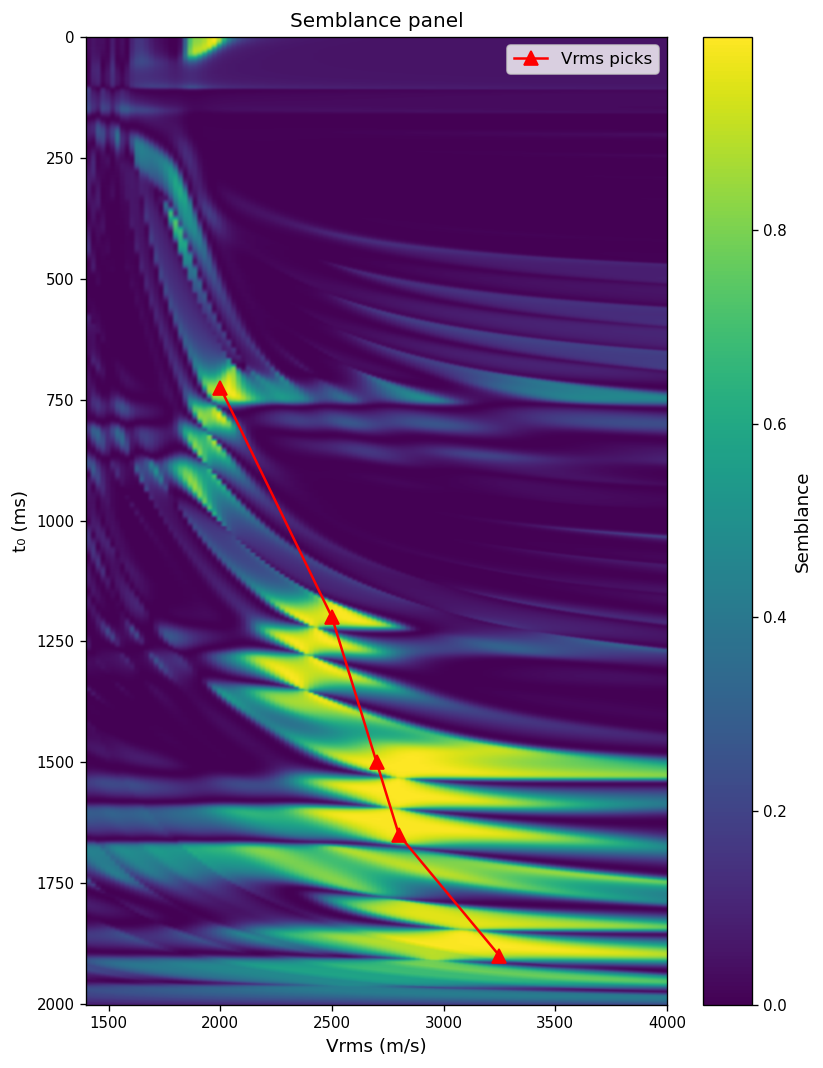

Figure 5: Semblance with Vrms picks (red triangles).

Pick table:
     t0 (ms)    Vrms (m/s)
       725.0        2000.0
      1200.0        2500.0
      1500.0        2700.0
      1650.0        2800.0
      1900.0        3250.0


In [9]:
# ── Manual velocity picks ──────────────────────────────────────────────────────

picks = np.array([
    # t0 (ms)   Vrms (m/s)
    [  725,      2000 ],
    [  1200,      2500 ],
    [  1500,     2700 ],
    [1650,      2800 ],
    [ 1900,      3250 ],
])

t0_picks   = picks[:, 0]   # ms
vrms_picks = picks[:, 1]   # m/s

# ── Re-plot semblance with picks overlaid ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 9))
nmo.plot_semblance(semblance, t0_axis, v_axis,
                   picks_t0=t0_picks, picks_v=vrms_picks, ax=ax)
plt.tight_layout()
plt.show()

print('Figure 5: Semblance with Vrms picks (red triangles).')
print('\nPick table:')
print(f'  {"t0 (ms)":>10}  {"Vrms (m/s)":>12}')
for t0, v in zip(t0_picks, vrms_picks):
    print(f'  {t0:>10.1f}  {v:>12.1f}')

---
## Step 6 — Vrms–t₀ Profile

The picked pairs are interpolated linearly to create a **continuous RMS velocity function**
$V_{\text{rms}}(t_0)$ that will drive the NMO correction.  The profile is plotted with
depth increasing downward (time axis inverted) as is conventional in reflection seismology.

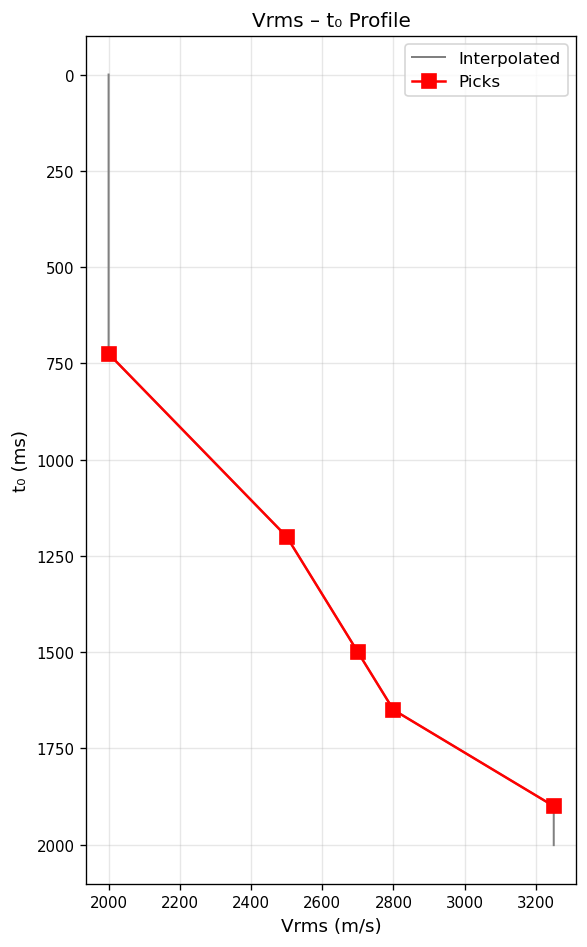

Figure 6: Vrms–t₀ profile.  Gray line = linear interpolation; red markers = manual picks.


In [10]:
# ── Build continuous Vrms profile ─────────────────────────────────────────────
n_samp_full = cmp_gather['data'].shape[0]
t_full_ms   = np.arange(n_samp_full) * cmp_gather['dt']

vrms_interp = interp1d(
    t0_picks, vrms_picks,
    kind='linear', bounds_error=False,
    fill_value=(vrms_picks[0], vrms_picks[-1]),
)
vrms_profile = vrms_interp(t_full_ms)   # continuous Vrms(t0) in m/s

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 8))
nmo.plot_vrms_profile(
    t0_picks, vrms_picks,
    t0_full=t_full_ms, vrms_full=vrms_profile,
    ax=ax,
)
plt.tight_layout()
plt.show()
print('Figure 6: Vrms–t₀ profile.  Gray line = linear interpolation; '
      'red markers = manual picks.')

---
## Step 7 — NMO Correction

NMO correction **flattens** each reflection hyperbola by time-shifting every sample
in each trace from its hyperbolic travel-time $t(x)$ back to the zero-offset time $t_0$:

$$t_0 = \sqrt{t(x)^2 - \frac{x^2}{V_{\text{rms}}^2}}$$

Sub-sample accuracy is achieved via **linear interpolation** in the original trace.

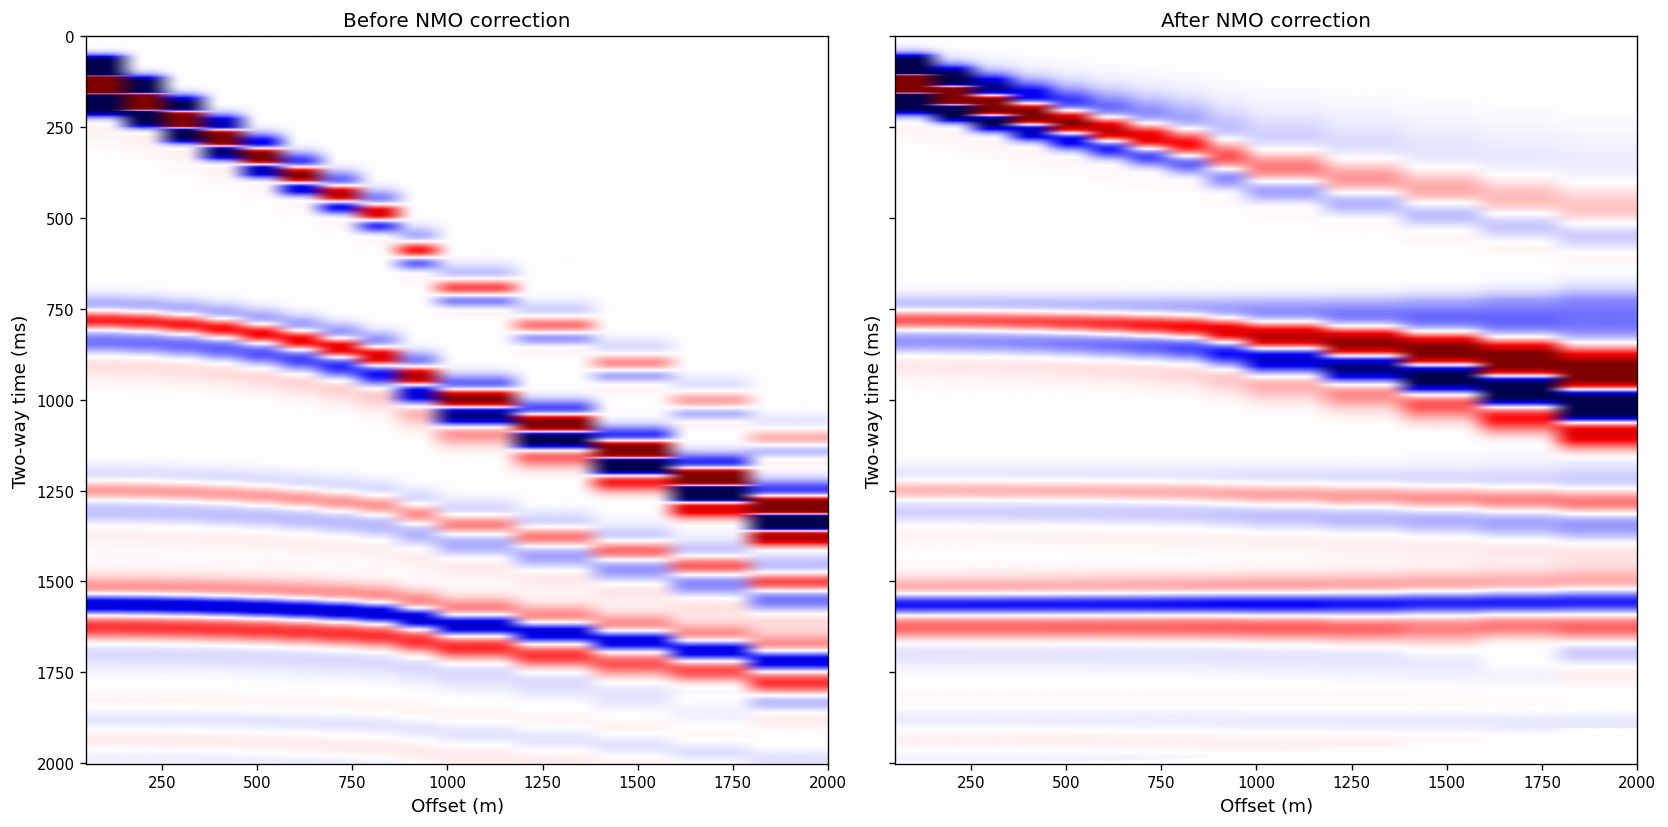

Figure 7: CMP gather before (left) and after (right) NMO correction.
Reflection events should be approximately horizontal after correction.


In [11]:
# ── Apply NMO correction ──────────────────────────────────────────────────────
corrected = nmo.nmo_correction(cmp_gather, t0_picks, vrms_picks)

# ── Side-by-side: before vs after ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

nmo.plot_cmp_gather(cmp_gather,
                    title='Before NMO correction', ax=axes[0])

# Build a temporary gather dict for the corrected data to reuse the plot function
corrected_gather = {**cmp_gather, 'data': corrected}
nmo.plot_cmp_gather(corrected_gather,
                    title='After NMO correction', ax=axes[1])

plt.tight_layout()
plt.show()
print('Figure 7: CMP gather before (left) and after (right) NMO correction.\n'
      'Reflection events should be approximately horizontal after correction.')

---
## Step 8 — Far-Offset Mute & Stacking

### Far-offset mute
At large offsets the NMO correction **stretches** the wavelet (NMO stretch distortion),
which degrades the stack.  We zero out all traces beyond a chosen maximum offset.

### Stacking
The surviving traces are averaged sample-by-sample to produce a single **stacked trace**
that represents the seismic image at the chosen CMP location.

In [12]:
# ── Far-offset mute ────────────────────────────────────────────────────────────
# Set MAX_OFFSET to ~60–70 % of the maximum recorded offset as a starting point.
MAX_OFFSET = 0.65 * cmp_gather['offsets'].max()   # metres
print(f"Max offset in gather : {cmp_gather['offsets'].max():.0f} m")
print(f"Mute threshold       : {MAX_OFFSET:.0f} m")

muted = nmo.apply_far_offset_mute(corrected, cmp_gather['offsets'], MAX_OFFSET)

# ── Stack ──────────────────────────────────────────────────────────────────────
stack = nmo.stack_gather(muted, cmp_gather['offsets'], MAX_OFFSET)
print(f"Stacked trace shape  : {stack.shape}")

Max offset in gather : 2000 m
Mute threshold       : 1300 m
Far-offset mute: kept 11/19 traces (max offset = 1300 m)
Stacked trace shape  : (1544,)


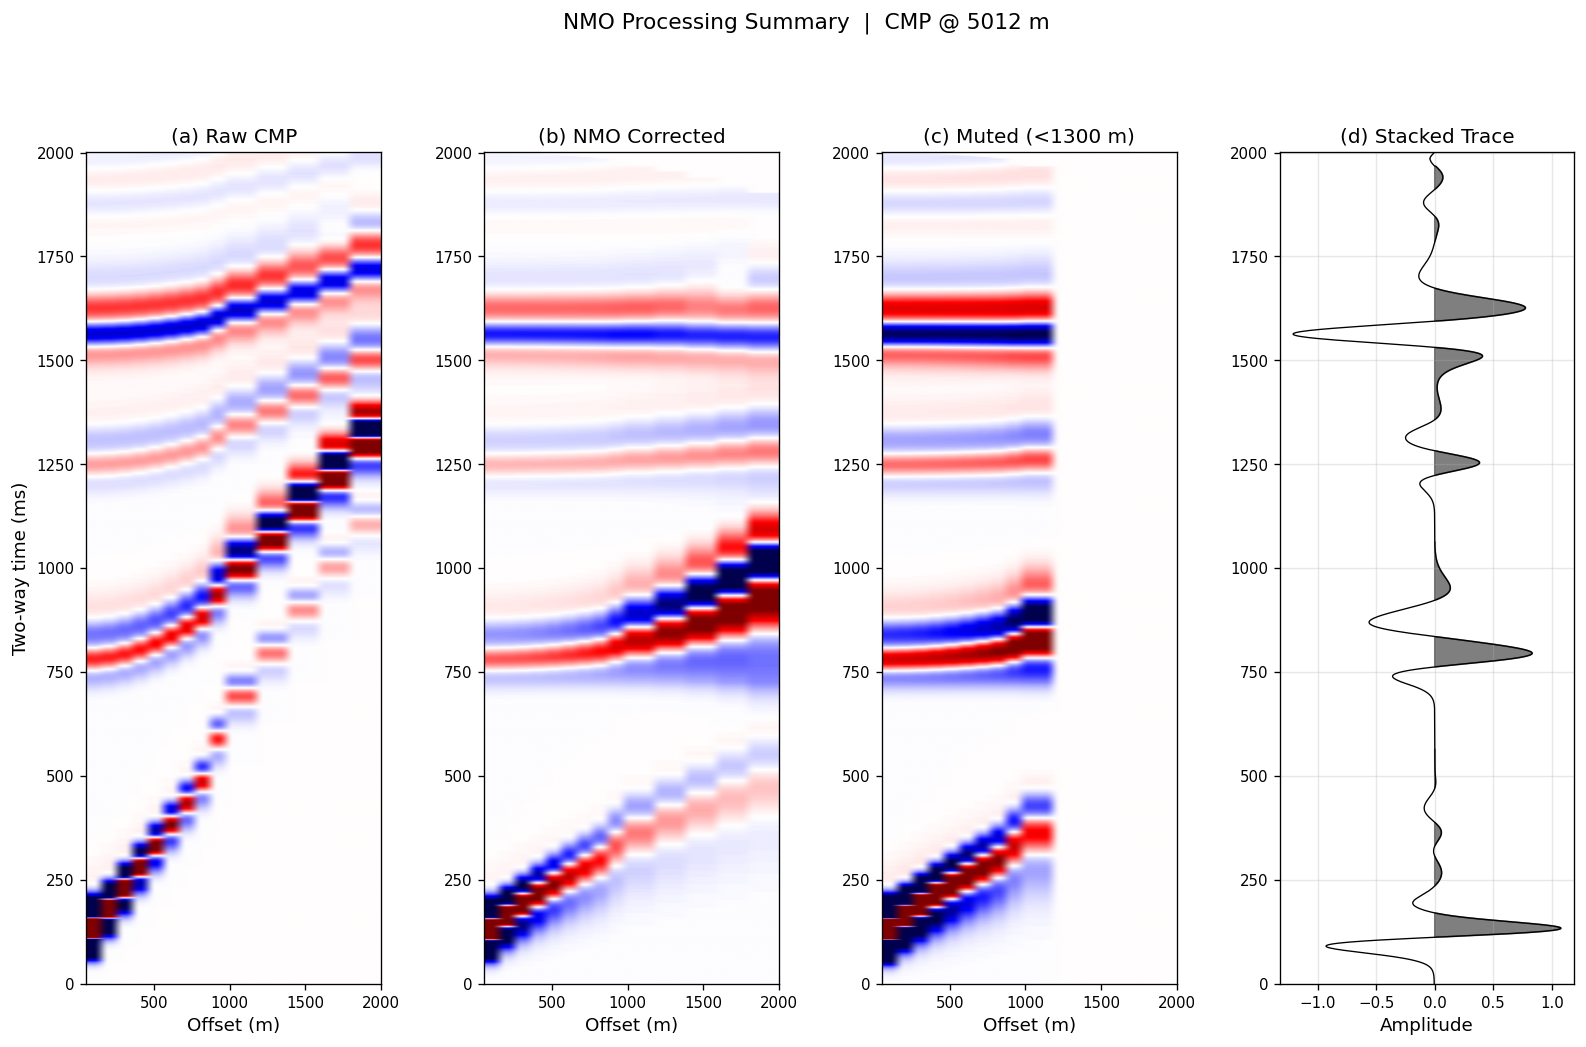

Figure 8: Full NMO processing chain.
(a) Raw gather → (b) NMO corrected → (c) Far-offset muted → (d) Stacked seismic image at CMP.


In [13]:
# ── Final four-panel summary figure ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)
ax4 = fig.add_subplot(gs[3], sharey=ax1)

# Panel 1: raw CMP gather
nmo.plot_cmp_gather(cmp_gather, title='(a) Raw CMP', ax=ax1)

# Panel 2: NMO-corrected gather
nmo.plot_cmp_gather(corrected_gather, title='(b) NMO Corrected', ax=ax2)
ax2.set_ylabel('')

# Panel 3: muted gather
muted_gather = {**cmp_gather, 'data': muted}
nmo.plot_cmp_gather(muted_gather, title=f'(c) Muted (<{MAX_OFFSET:.0f} m)', ax=ax3)
ax3.set_ylabel('')

# Panel 4: stacked trace
nmo.plot_stack_trace(stack, cmp_gather['dt'], ax=ax4)
ax4.set_title('(d) Stacked Trace')
ax4.set_ylabel('')

plt.suptitle(
    f'NMO Processing Summary  |  CMP @ {CMP_TARGET:.0f} m',
    fontsize=13, y=1.01,
)
#plt.tight_layout()
plt.show()

print('Figure 8: Full NMO processing chain.\n'
      '(a) Raw gather → (b) NMO corrected → (c) Far-offset muted → '
      '(d) Stacked seismic image at CMP.')

---
## Summary

| Step | Output |
|------|--------|
| 1 | Loaded **N** shot gathers from `multi_shots/` |
| 2 | Computed CMP x-coordinates and offsets for every trace |
| 3 | Identified high-fold CMP zone via histogram |
| 4 | Extracted CMP gather at selected location with chosen bin size |
| 5 | Computed semblance panel; picked (t₀, Vrms) pairs at reflection peaks |
| 6 | Interpolated Vrms–t₀ profile |
| 7 | Applied NMO correction using the Vrms profile (linear interpolation) |
| 8 | Applied far-offset mute; produced single stacked seismic trace |

### Key Parameters Used

```
CMP centre   : CMP_TARGET m
Bin size     : BIN_SIZE m  (±BIN_SIZE/2 m)
Velocity range tested : V_MIN – V_MAX m/s
Far-offset mute threshold : MAX_OFFSET m
```

All processing functions are documented in **`nmo_lib.py`**.